In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


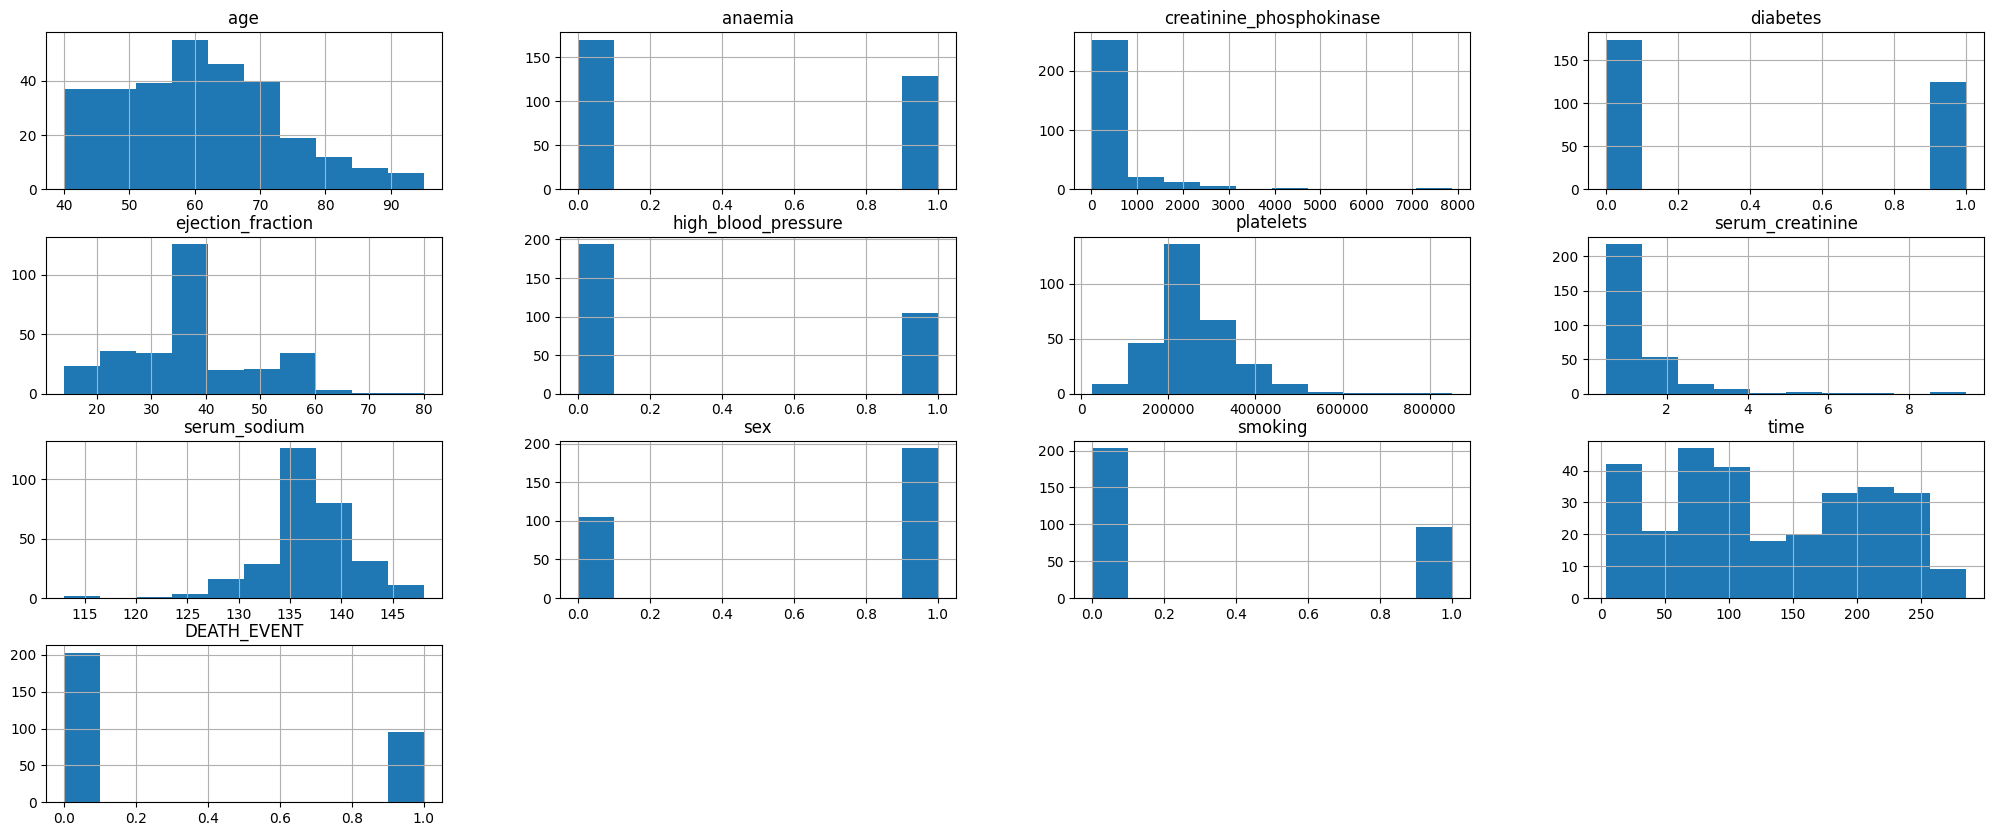

In [ ]:
df.hist(df.columns, figsize=(25,10))
plt.show()

In [ ]:
df.isnull().sum().max()

0

In [ ]:
x = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)
x_scaled_df.head(4)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,-1.629502
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,-1.603691
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,-1.590785
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,-1.590785


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
y_train.shape, y_test.shape

((239,), (60,))

In [ ]:
from sklearn import neighbors
knn = neighbors.KNeighborsClassifier(n_neighbors= 5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_train_predicted = knn.predict(x_train)
y_test_predicted = knn.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

accuracy_train = accuracy_score(y_train, y_train_predicted)
accuracy_test = accuracy_score(y_test, y_test_predicted)
f1_train = f1_score(y_train, y_train_predicted)
f1_test = f1_score(y_test, y_test_predicted)
precision_train = precision_score(y_train, y_train_predicted)
precision_test = precision_score(y_test, y_test_predicted)

print(f'оценка точности классификации: {accuracy_train}, {accuracy_test}')
print(f'F1: {f1_train}, {f1_test}')
print(f'точность: {precision_train}, {precision_test}')

оценка точности классификации: 0.7656903765690377, 0.48333333333333334
F1: 0.5172413793103449, 0.20512820512820512
точность: 0.6976744186046512, 0.25


In [ ]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y)
x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size = 0.2, random_state = 0)
y_train2.shape, y_test2.shape

((239,), (60,))

In [ ]:
from sklearn.svm import SVC
svc_model = SVC(class_weight='balanced')
svc_model.fit(x_train2, y_train2)

SVC(class_weight='balanced')

In [ ]:
y_train_predicted2 = svc_model.predict(x_train2)
y_test_predicted2 = svc_model.predict(x_test2)

In [ ]:
accuracy_train2 = accuracy_score(y_train2, y_train_predicted2)
accuracy_test2 = accuracy_score(y_test2, y_test_predicted2)
f1_train2 = f1_score(y_train2, y_train_predicted2)
f1_test2 = f1_score(y_test2, y_test_predicted2)
precision_train2 = precision_score(y_train2, y_train_predicted2)
precision_test2 = precision_score(y_test2, y_test_predicted2)

print(f'оценка точности классификации: {accuracy_train2}, {accuracy_test2}')
print(f'F1: {f1_train2}, {f1_test2}')
print(f'точность: {precision_train2}, {precision_test2}')

оценка точности классификации: 0.6443514644351465, 0.6333333333333333
F1: 0.19047619047619047, 0.35294117647058826
точность: 0.3125, 0.5454545454545454


In [ ]:
x_train3, x_test3, y_train3, y_test3 = train_test_split(x, y)
x_train3, x_test3, y_train3, y_test3 = train_test_split(x, y, test_size = 0.2, random_state = 0)
y_train3.shape, y_test3.shape

((239,), (60,))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
Classifier = DecisionTreeClassifier()
Classifier.fit(x_train3, y_train3)

DecisionTreeClassifier()

In [ ]:
y_train_predicted3 = Classifier.predict(x_train3)
y_test_predicted3 = Classifier.predict(x_test3)

In [ ]:
accuracy_train3 = accuracy_score(y_train3, y_train_predicted3)
accuracy_test3 = accuracy_score(y_test3, y_test_predicted3)
f1_train3 = f1_score(y_train3, y_train_predicted3)
f1_test3 = f1_score(y_test3, y_test_predicted3)
precision_train3 = precision_score(y_train3, y_train_predicted3)
precision_test3 = precision_score(y_test3, y_test_predicted3)

print(f'оценка точности классификации: {accuracy_train3}, {accuracy_test3}')
print(f'F1: {f1_train3}, {f1_test3}')
print(f'точность: {precision_train3}, {precision_test3}')

оценка точности классификации: 1.0, 0.75
F1: 1.0, 0.6666666666666666
точность: 1.0, 0.6818181818181818


In [ ]:
from sklearn.model_selection import GridSearchCV
knn = neighbors.KNeighborsClassifier()

params = {'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'metric':['euclidean','cityblock']}
grid = GridSearchCV(estimator = knn, param_grid = params)
grid.fit(x_train, y_train)
print(grid.best_score_)
print(grid.best_estimator_.n_neighbors)
print(grid.best_estimator_.metric)

0.6821808510638298
10
euclidean


In [ ]:
x_train4, x_test4, y_train4, y_test4 = train_test_split(x, y)
x_train4, x_test4, y_train4, y_test4 = train_test_split(x, y, test_size = 0.2, random_state = 0)
y_train4.shape, y_test4.shape

((239,), (60,))

In [ ]:
knn2 = neighbors.KNeighborsClassifier(n_neighbors= 10)
knn2.fit(x_train4, y_train4)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
y_train_predicted4 = knn2.predict(x_train4)
y_test_predicted4 = knn2.predict(x_test4)

In [ ]:
accuracy_train4 = accuracy_score(y_train4, y_train_predicted4)
accuracy_test4 = accuracy_score(y_test4, y_test_predicted4)
f1_train4 = f1_score(y_train4, y_train_predicted4)
f1_test4 = f1_score(y_test4, y_test_predicted4)
precision_train4 = precision_score(y_train4, y_train_predicted4)
precision_test4 = precision_score(y_test4, y_test_predicted4)

print(f'оценка точности классификации: {accuracy_train}, {accuracy_test}')
print(f'F1: {f1_train}, {f1_test}')
print(f'точность: {precision_train}, {precision_test}')

print(f'\nоценка точности классификации после гиперпараметров: {accuracy_train4}, {accuracy_test4}')
print(f'F1 после гиперпараметров : {f1_train4}, {f1_test4}')
print(f'точность после гиперпараметров: {precision_train4}, {precision_test4}')

оценка точности классификации: 0.7656903765690377, 0.48333333333333334
F1: 0.5172413793103449, 0.20512820512820512
точность: 0.6976744186046512, 0.25

оценка точности классификации после гиперпараметров: 0.6861924686192469, 0.65
F1 после гиперпараметров : 0.07407407407407407, 0.16
точность после гиперпараметров: 0.375, 1.0


In [ ]:
data = {
    'accuracy train': [accuracy_train, accuracy_train2, accuracy_train3, accuracy_train4],
    'accuracy test': [accuracy_test, accuracy_test2, accuracy_test3, accuracy_test4],
    'F1 train': [f1_train, f1_train2, f1_train3, f1_train4],
    'F1 test': [f1_test, f1_test2, f1_test3, f1_test4],
    'precision train': [precision_train, precision_train2, precision_train3, precision_train4],
    'precision test': [precision_test, precision_test2, precision_test3, precision_test4]
}

index = ['Соседи', 'SVC', 'Дерево решений', 'После поиска гиперпараметров соседи']

dfs = pd.DataFrame(data, index = index)
dfs.head(4)

,accuracy train,accuracy test,F1 train,F1 test,precision train,precision test
Соседи,0.765690,0.483333,0.517241,0.205128,0.697674,0.250000
SVC,0.644351,0.633333,0.190476,0.352941,0.312500,0.545455
Дерево решений,1.000000,0.750000,1.000000,0.666667,1.000000,0.681818
После поиска гиперпараметров соседи,0.686192,0.650000,0.074074,0.160000,0.375000,1.000000
